In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pathlib

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os

print(os.listdir('/content/drive/MyDrive/CNN_TL'))

import zipfile
import os

zip_path = "/content/drive/MyDrive/CNN_TL/kagglecatsanddogs_5340.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extract selesai!")

print(os.listdir("/content/dataset"))

import tensorflow as tf

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/PetImages",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/PetImages",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print(train_dataset.class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['kagglecatsanddogs_5340.zip']
Extract selesai!
['CDLA-Permissive-2.0.pdf', 'readme[1].txt', 'PetImages']
Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
['Cat', 'Dog']


False


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_44 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_19 (Sequential)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_13 (TrueDivide)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_13 (Subtract)          │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Deleted 0 images
Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.
Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9478 - loss: 0.1216 - val_accuracy: 0.9814 - val_loss: 0.0542
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.9665 - loss: 0.0860 - val_accuracy: 0.9821 - val_loss: 0.0536
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.9674 - loss: 0.0833 - val_accuracy: 0.9838 - val_loss: 0.0491
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.9669 - loss: 0.0818 - val_accuracy: 0.9823 - val_loss: 0.0483
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.9683 - loss: 0.0810 - val_accuracy: 0.9827 - val_loss: 0.0454
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9827 - loss: 0.0454
Validation Loss : 0.04544306546449661
Validation Accuracy : 0.9826996922492981


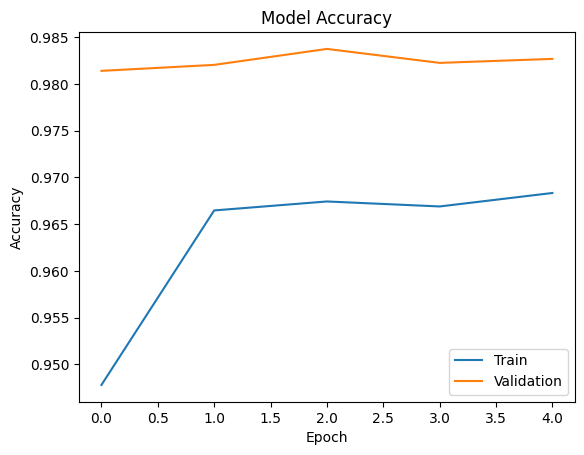

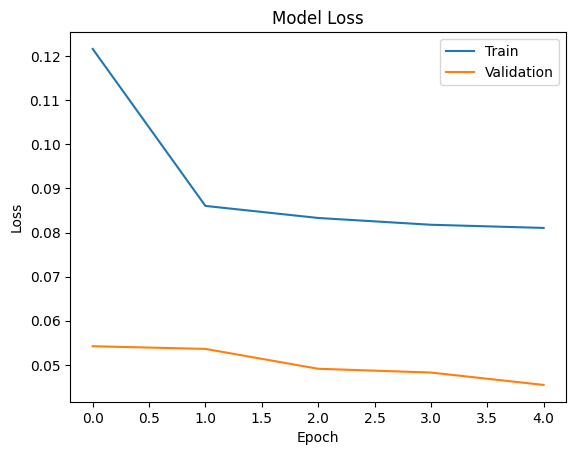

In [34]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

IMG_SHAPE = IMG_SIZE + (3,)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

print(base_model.trainable)

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

prediction_layer = tf.keras.layers.Dense(1)

inputs = tf.keras.Input(shape=(160,160,3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = global_average_layer(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

import os

num_skipped = 0

for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("/content/dataset/PetImages", folder_name)

    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)

        try:
            with open(fpath, "rb") as fobj:
                is_jfif = b"JFIF" in fobj.peek(10)

        except:
            is_jfif = False

        if not is_jfif:
            num_skipped += 1
            os.remove(fpath)

print("Deleted", num_skipped, "images")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/PetImages",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(160,160),
    batch_size=32
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/PetImages",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(160,160),
    batch_size=32
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

base_model.trainable = True

In [37]:
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

    model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(1e-5),
    metrics=['accuracy']
)

    fine_tune_epochs = 5

total_epochs = 10

history_fine = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]
)

Epoch 5/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 61s 80ms/step - accuracy: 0.9293 - loss: 0.1876 - val_accuracy: 0.9808 - val_loss: 0.0787
Epoch 6/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 80s 78ms/step - accuracy: 0.9540 - loss: 0.1152 - val_accuracy: 0.9840 - val_loss: 0.0525
Epoch 7/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 81s 77ms/step - accuracy: 0.9608 - loss: 0.0980 - val_accuracy: 0.9840 - val_loss: 0.0502
Epoch 8/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 46s 78ms/step - accuracy: 0.9642 - loss: 0.0865 - val_accuracy: 0.9842 - val_loss: 0.0506
Epoch 9/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 46s 78ms/step - accuracy: 0.9682 - loss: 0.0792 - val_accuracy: 0.9842 - val_loss: 0.0505
Epoch 10/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 83s 79ms/step - accuracy: 0.9699 - loss: 0.0743 - val_accuracy: 0.9831 - val_loss: 0.0541


In [38]:
loss, accuracy = model.evaluate(validation_dataset)

print("Final Accuracy :", accuracy)

147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9831 - loss: 0.0541
Final Accuracy : 0.9831268787384033


In [39]:
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predictions = tf.nn.sigmoid(predictions)
    predictions = (predictions > 0.5).numpy().astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

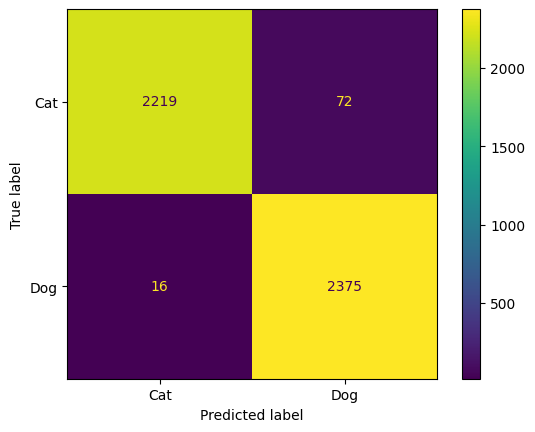

In [41]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat","Dog"]
)

disp.plot()

plt.show()

In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Cat","Dog"]
    )
)

              precision    recall  f1-score   support

         Cat       0.99      0.97      0.98      2291
         Dog       0.97      0.99      0.98      2391

    accuracy                           0.98      4682
   macro avg       0.98      0.98      0.98      4682
weighted avg       0.98      0.98      0.98      4682



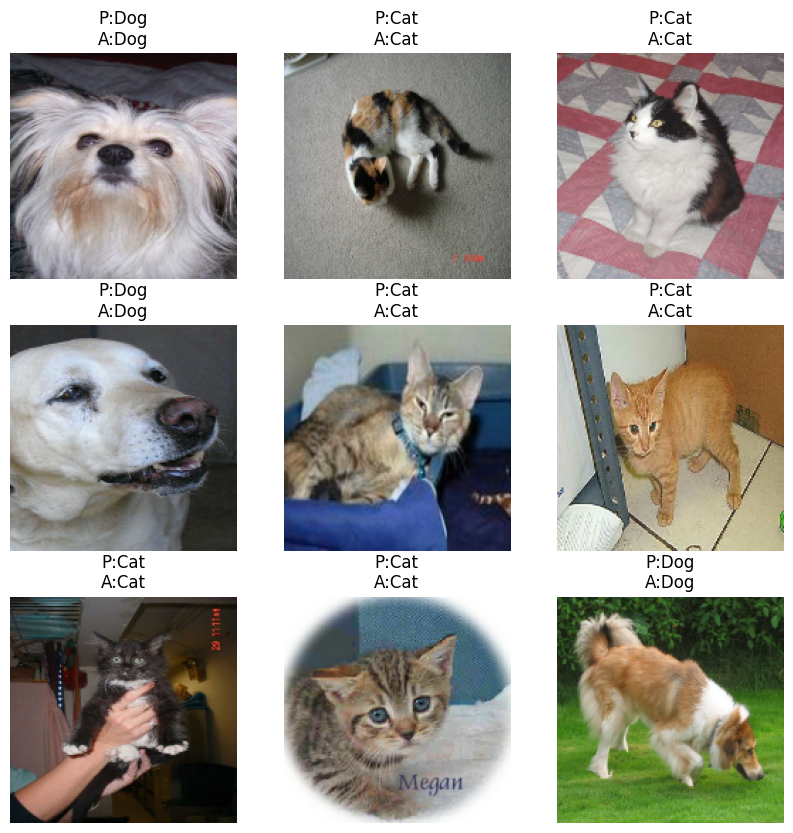

In [44]:
plt.figure(figsize=(10,10))

for images, labels in validation_dataset.take(1):

    predictions = model.predict(images, verbose=0)
    predictions = tf.nn.sigmoid(predictions)
    predictions = (predictions > 0.5).numpy().astype(int)

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        pred = "Dog" if predictions[i] else "Cat"
        actual = "Dog" if labels[i] else "Cat"

        plt.title(f"P:{pred}\nA:{actual}")

        plt.axis("off")

plt.show()